In [68]:
#using PlotlyJS
using UMAP: umap
using Plots

using PyCall
@pyimport umap as py_umap;

include("../src/fxio.jl")
include("../src/kabsch_umeyama.jl")

vtor (generic function with 1 method)

In [69]:
f = open("../data/dssp.csv") 
dssp = Dict()
for line in readlines(f) 
    key_seq = split(line, ",")
    dssp[key_seq[1]] = key_seq[2]
end

In [70]:
function convertdssp(dssp4mer)

    for i in 1:length(dssp4mer)
        if contains(dssp4mer[i], "HHH")
            dssp4mer[i] = "red"
        elseif  contains(dssp4mer[i], "EE")
            dssp4mer[i] = "blue"
        elseif  contains(dssp4mer[i], "TT")
            dssp4mer[i] = "green"
        else 
            dssp4mer[i] = "gray"
        end
    end
    
    return dssp4mer
end

function pdb2vtors(pdbpath)
    seqxyz = pdb2seqxyz(pdbpath)
    kmers = coords2kmers(seqxyz, 4, "ca")

    vtors = zeros(Float64, length(kmers), 3)
    
    for (i, kmer) in enumerate(kmers)
        vtors[i,1:3] = vtor(kmer[:,2:4])
    end
    
    return vtors
end


pdb2vtors (generic function with 1 method)

In [ ]:
scoppath = "../../scop40NR/" 
virtual_torsions = reshape(Float64[], 0, 3)
sscolors = []
for pdb in readdir(scoppath)

    try
        pdbpath = joinpath(scoppath, pdb)
        id = basename(pdbpath)[1:end-4]

        dsspcolors = convertdssp(seq2kmers(dssp[id], 4))
        vtors = pdb2vtors(pdbpath)   
        if size(vtors, 1) == length(dsspcolors) #& not isnan(vtors)
            virtual_torsions = vcat(virtual_torsions, vtors)
            sscolors = vcat(sscolors, dsspcolors)
        else
            println(id)
        end

    catch

        println(pdb)
    
    end
end

In [80]:
range = 1:5000
virtual_torsions[range,:]

5000×3 Matrix{Float64}:
   48.5349  90.7727  87.5446
   47.7187  87.5446  85.9703
   44.4653  85.9703  88.5162
   58.3254  88.5162  90.4655
   44.8667  90.4655  87.5771
   55.7185  87.5771  89.5807
   48.6603  89.5807  86.7691
   50.8015  86.7691  86.1645
   51.3344  86.1645  87.0752
   46.9491  87.0752  82.8114
    ⋮                
   49.5111  85.8057  91.3383
   47.4949  91.3383  84.5371
   50.931   84.5371  89.9939
   48.9067  89.9939  79.3237
   50.778   79.3237  93.3394
   55.8003  93.3394  87.6608
   40.6894  87.6608  88.8983
 -117.926   88.8983  76.2571
  166.375   76.2571  71.2223

In [81]:
umap_model = umap(virtual_torsions[range,:]'; n_neighbors=15, min_dist=0.01, n_epochs=200)
print(size(umap_model))

(2, 5000)

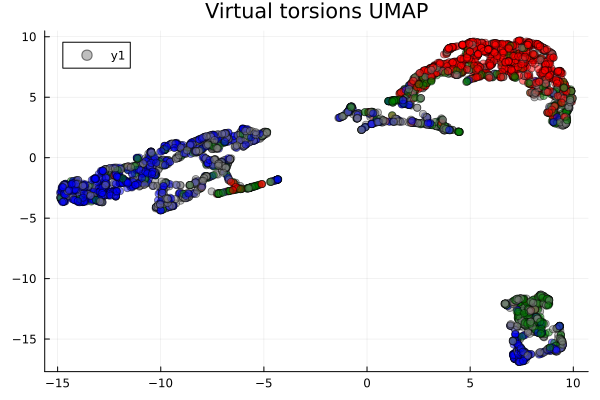

In [82]:
scatter(umap_model[1,:], umap_model[2,:], color=sscolors[range], title="Virtual torsions UMAP", markersize=4, alpha=0.5)

In [83]:
py_umap_model = py_umap.UMAP(n_neighbors=15, min_dist=0.01, n_epochs=200)[:fit_transform](permutedims(virtual_torsions[range,:]')) 
print(size(umap_model))

(2, 5000)

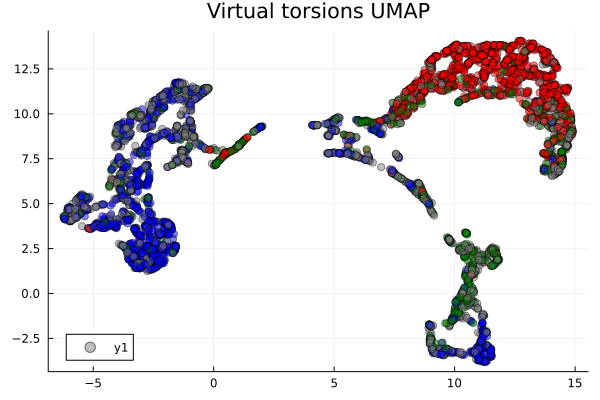

In [84]:
scatter(py_umap_model[:,1], py_umap_model[:,2], color=sscolors[range], title="Virtual torsions UMAP", markersize=4, alpha=0.5)

In [ ]:
seqxyz = pdb2seqxyz(pdbpath)

function catrace(seqxyz)

    trace_points = scatter3d(
            x=seqxyz[:,2], y=seqxyz[:,3], z=seqxyz[:,4],
            mode="markers+text",
            marker=attr(size=2, color="red"),
            text=seqxyz[:,1],
            textposition="top center"
        )

    trace_lines = scatter3d(
            x=seqxyz[:,2], y=seqxyz[:,3], z=seqxyz[:,4],
            mode="lines",
            line=attr(width=4, color="blue")
        )
        
    layout = Layout(
            title="Dihedral Angle Visualization",
            width=800,    # Set plot width
            height=600,   # Set plot height
            scene=attr(
                xaxis=attr(visible=false),
                yaxis=attr(visible=false),
                zaxis=attr(visible=false),
                camera=attr(
                    projection=attr(type="orthographic")  # Set perspective view
                )
            )
        )

    return plot([trace_lines, trace_points], layout)
end

catrace(seqxyz)